#  Support Vector Regression (SVR) : Simplest Notes

##  Summary
Support Vector Regression (SVR) is different from Linear Regression because it uses an **epsilon-insensitive tube**.  
- Errors inside the tube are ignored.  
- Errors outside the tube are considered important → these points are called **support vectors**.  

---

##  Highlights
-  Invented in the 1990s by **Vladimir Vapnik** and colleagues at AT&T Bell Labs.  
-  SVR allows small errors (within epsilon tube) → focuses only on large errors.  
-  Linear Regression minimizes squared errors (Ordinary Least Squares).  
-  SVR minimizes the sum of distances of points **outside** the tube.  
-  **Support vectors** = points outside the tube → they define the tube’s shape.  
-  Reference: *Efficient Learning Machines* by Mariette Awad & Rahul Khanna.  

---

##  Visual Intuition
- Imagine a tube around the regression line.  
- Points inside tube → ignored.  
- Points outside tube → matter (support vectors).  

---

#  Non-Linear SVR (RBF Kernel) 

##  Core Concept
- Linear SVR fits straight-line relationships, but many real-world problems are **non-linear**.  
- To capture curves and complex patterns, SVR uses the **kernel trick**.  
- The kernel trick allows SVR to operate in a higher-dimensional space without explicitly computing the transformation.

---

##  RBF Kernel Explained
- **RBF (Radial Basis Function)** kernel is the most widely used in SVR.  
- It measures similarity between two points based on their distance:  
  - Close points → high similarity.  
  - Far points → low similarity.  
- This enables SVR to create flexible, curved decision boundaries that adapt to the data.

---

##  Transition from Linear to Non-Linear
- **Linear SVR**: builds a tube around a straight line.  
- **Non-linear SVR (RBF)**: builds a tube around a curved function that bends to fit the data.  
- The model can capture oscillations, peaks, and valleys that linear SVR cannot.

---

##  Importance of SVM Intuition
- Understanding **support vectors** and the **epsilon-insensitive tube** is crucial before moving to kernels.  
- Kernels extend the same principle: support vectors outside the tube define the curve in higher-dimensional space.  
- Without this intuition, kernel SVR feels like a “black box.”

---

##  Practical Choice
- Learners can either:  
  - Jump directly into non-linear SVR with RBF kernel.  
  - Or first build intuition with linear SVR, then transition.  
- Both paths are valid, but deeper understanding of SVM mechanics makes kernel SVR more transparent.

---

##  Key Takeaway
- **Linear SVR** handles straight-line fits.  
- **RBF Kernel SVR** handles complex, non-linear patterns using the kernel trick.  
- The essence remains the same: focus on support vectors outside the tube, but now in a transformed space that allows curved fits.  

In [2]:
# Support Vector Regression (SVR)

# Importing the libraries
import numpy as np          # For numerical operations and arrays
import matplotlib.pyplot as plt  # For plotting graphs and visualizations
import pandas as pd         # For handling datasets in tabular form (DataFrames)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

In [3]:
# Importing the dataset
dataset = pd.read_csv('Position_Salaries_100_Realistic.csv')   # Load CSV file into a DataFrame
X = dataset.iloc[:, 1:-1].values                 # Select all rows, 2nd column only (Position level)
y = dataset.iloc[:, -1].values                   # Select all rows, last column (Salary)

print(X)   # Shows the feature matrix (levels)

[[15]
 [ 1]
 [ 3]
 [13]
 [ 8]
 [11]
 [11]
 [ 2]
 [ 9]
 [ 4]
 [14]
 [ 2]
 [ 9]
 [14]
 [ 6]
 [13]
 [ 3]
 [15]
 [14]
 [10]
 [ 9]
 [ 6]
 [11]
 [10]
 [ 3]
 [10]
 [14]
 [ 9]
 [ 6]
 [15]
 [14]
 [ 4]
 [14]
 [ 9]
 [14]
 [ 6]
 [ 7]
 [13]
 [13]
 [ 8]
 [12]
 [10]
 [ 2]
 [ 6]
 [ 1]
 [ 8]
 [ 5]
 [14]
 [11]
 [ 3]
 [10]
 [ 8]
 [ 5]
 [15]
 [15]
 [ 6]
 [11]
 [ 5]
 [ 2]
 [15]
 [ 3]
 [12]
 [11]
 [10]
 [12]
 [ 5]
 [ 4]
 [ 8]
 [14]
 [ 9]
 [ 8]
 [ 6]
 [ 5]
 [ 4]
 [ 1]
 [ 6]
 [ 1]
 [ 5]
 [ 7]
 [13]
 [15]
 [14]
 [10]
 [ 6]
 [14]
 [12]
 [14]
 [ 3]
 [14]
 [ 3]
 [ 4]
 [ 9]
 [14]
 [ 2]
 [12]
 [ 9]
 [ 3]
 [14]
 [14]
 [ 3]]


In [4]:
dataset.tail()

,Position,Level,Salary
95,Role 96 - Vice President,9,196268
96,Role 97 - Engineer,3,61084
97,Role 98 - President,14,460435
98,Role 99 - President,14,492991
99,Role 100 - Engineer,3,63442


In [5]:
print(y)   # Shows the target vector (salaries)

[798611  35051  61254 387345 141319 259154 240128  47509 183960  71857
 585863  48371 188967 510853 102232 353406  60323 763026 566226 210317
 178491  99884 282213 202829  60372 192815 496701 171319 115474 663265
 488272  62142 547927 179320 463908 119100 118927 352178 353543 150824
 341126 218257  44848  90608  44675 131120  98503 474170 240303  51297
 230078 131021  83350 620767 675803 108058 277290  91362  41930 672552
  63957 304018 285439 191506 284182  81555  72157 143609 543202 190250
 130615 100936  92281  79187  44042 108633  37884  93366 119818 422745
 711721 483771 224460 102039 566341 314230 585797  52655 519080  53817
  79649 185144 539517  49357 288087 196268  61084 460435 492991  63442]


In [6]:
y = y.reshape(len(y),1)                          # Reshape y into a column vector

In [7]:
print(y)   # Shows y in 2D array form

[[798611]
 [ 35051]
 [ 61254]
 [387345]
 [141319]
 [259154]
 [240128]
 [ 47509]
 [183960]
 [ 71857]
 [585863]
 [ 48371]
 [188967]
 [510853]
 [102232]
 [353406]
 [ 60323]
 [763026]
 [566226]
 [210317]
 [178491]
 [ 99884]
 [282213]
 [202829]
 [ 60372]
 [192815]
 [496701]
 [171319]
 [115474]
 [663265]
 [488272]
 [ 62142]
 [547927]
 [179320]
 [463908]
 [119100]
 [118927]
 [352178]
 [353543]
 [150824]
 [341126]
 [218257]
 [ 44848]
 [ 90608]
 [ 44675]
 [131120]
 [ 98503]
 [474170]
 [240303]
 [ 51297]
 [230078]
 [131021]
 [ 83350]
 [620767]
 [675803]
 [108058]
 [277290]
 [ 91362]
 [ 41930]
 [672552]
 [ 63957]
 [304018]
 [285439]
 [191506]
 [284182]
 [ 81555]
 [ 72157]
 [143609]
 [543202]
 [190250]
 [130615]
 [100936]
 [ 92281]
 [ 79187]
 [ 44042]
 [108633]
 [ 37884]
 [ 93366]
 [119818]
 [422745]
 [711721]
 [483771]
 [224460]
 [102039]
 [566341]
 [314230]
 [585797]
 [ 52655]
 [519080]
 [ 53817]
 [ 79649]
 [185144]
 [539517]
 [ 49357]
 [288087]
 [196268]
 [ 61084]
 [460435]
 [492991]
 [ 63442]]

##  Why Reshape in SVR?

### 1. Data Shape in Regression
- In **Simple Linear Regression** and **Multiple Linear Regression**, `y` can remain as a 1D array (shape `(n,)`).
- The regression functions in scikit-learn (`LinearRegression`) accept `y` in that form without issue.

### 2. SVR’s Expectation
- **Support Vector Regression (SVR)** internally works with optimization routines that often expect `y` to be a **column vector** (shape `(n,1)`).
- Reshaping ensures `y` is treated as a proper 2D array, aligning with how SVR handles support vectors and kernel computations.

### 3. Why the Difference?
- Linear regression is simpler: it just minimizes squared errors, so a flat 1D target vector is fine.
- SVR uses the **epsilon-insensitive loss** and kernel trick. These require consistent matrix operations, so `y` must be explicitly reshaped into `(rows, columns)` form.

### 4. Practical Note
- If you skip reshape, SVR may still run in some cases, but reshaping avoids dimension mismatch errors in later steps (especially when scaling `y` or applying transformations).
- That’s why we often reshape `y` for SVR, but not for linear regression.

---

### Key Takeaway
- **Linear Regression** → `y` can stay 1D.  
- **SVR** → safer to reshape `y` into 2D `(n,1)` because of how kernels and support vectors are computed.  


In [8]:
# Train-Test Split

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", len(X_train))
print("Testing set size:", len(X_test))

Training set size: 80
Testing set size: 20


##  Feature Scaling Workflow (Train-Test Split)

### Step 1: Train-Test Split
You first split your data into `X_train, X_test, y_train, y_test`.  
This ensures the model learns only from training data.

---

### Step 2: Why Reshape `y`
- `y` is originally a **1D array** (shape `(n,)`).  
- Some scalers (like `StandardScaler`) expect a **2D array** (shape `(n,1)`).  
- `reshape(-1,1)` simply converts your target into a column vector.  
  - Example: `[45000, 50000, 60000]` → `[[45000],[50000],[60000]]`.

This is not changing values, just the shape so the scaler can work properly.

---

### Step 3: Fit vs Transform
- **`fit()`** → calculates the mean and standard deviation of the training data.  
- **`transform()`** → applies those scaling rules to data.  
- **`fit_transform()`** → does both in one step.

Rule:  
- Use `fit_transform()` on **training data**.  
- Use `transform()` on **test data** (so test data is scaled using training statistics, avoiding leakage).

---

### Step 4: Correct Workflow


In [9]:
from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()
sc_y = StandardScaler()

# Scale X
X_train = sc_X.fit_transform(X_train)   # learn + scale training features
X_test = sc_X.transform(X_test)         # scale test features using training stats

# Scale y
y_train = y_train.reshape(-1,1)         # reshape to column vector
y_test = y_test.reshape(-1,1)

y_train = sc_y.fit_transform(y_train)   # learn + scale training target
y_test = sc_y.transform(y_test)         # scale test target using training stats


#  Feature Scaling  Mini Topic: StandardScaler

###  Why Scaling Matters
- Machine learning models often rely on **distances** or **gradients**.  
- If one feature has values in thousands and another in decimals, the larger scale dominates.  
- Scaling ensures all features contribute fairly.

---

###  Types of Scaling
1. **Min-Max Scaling (Normalization)**  
   - Rescales values into a fixed range, usually [0,1].  
   - Formula: `(x - min) / (max - min)`  
   - Good when you want bounded values.

2. **Standardization (Z-score Scaling)**  
   - Rescales values to have **mean = 0** and **standard deviation = 1**.  
   - Formula: `(x - mean) / std`  
   - Good when data follows a Gaussian-like distribution.

3. **Robust Scaling**  
   - Uses **median** and **interquartile range (IQR)**.  
   - Less sensitive to outliers.  
   - Formula: `(x - median) / IQR`.

---

### StandardScaler : Deep Dive
- **What it is:** A scikit-learn tool that applies **Z-score scaling**.  
- **How it looks:** After scaling, values are centered around 0, with spread adjusted so variance = 1.  
- **Where it’s used:**  
  - Algorithms sensitive to scale (SVM, SVR, KNN, PCA, Logistic Regression).  
  - Especially important in SVR because it uses **distance-based kernel functions**.  
- **Effect:**  
  - Raw values → transformed into standardized units.  
  - Example: Salary values like `45000, 50000, 1000000` become standardized numbers like `-0.72, -0.69, 2.52`.

---

### Key Takeaway
- **Scaling is essential** when models depend on distances or optimization.  
- **StandardScaler** is the most common method: it makes features comparable by centering them at 0 and scaling variance to 1.  
- Without scaling, SVR and other kernel-based methods can give biased or incorrect results.  


#  StandardScaler : Deep Clarification

###  Does StandardScaler Have a Range?
- **No fixed range.**  
- Unlike Min-Max scaling (which forces values into [0,1] or [-1,1]), StandardScaler does **not** bound values.  
- Instead, it transforms data so that:
  - Mean = 0  
  - Standard Deviation = 1  

---

### Why Do We See Values Like 2.52?
- StandardScaler computes:  
  

\[
  z = \frac{x - \mu}{\sigma}
  \]

  
  where \(x\) = original value, \(\mu\) = mean, \(\sigma\) = standard deviation.  

- Example with salaries:  
  - Mean ≈ 243,000  
  - Std Dev ≈ 382,000  
  - For 1,000,000:  
    

\[
    z = \frac{1,000,000 - 243,000}{382,000} \approx 2.52
    \]

  

- That’s why the scaled value is **2.52**  it’s 2.52 standard deviations above the mean.

---

### How Values Look
- Most values after scaling fall between **-3 and +3** (since ~99% of data in a normal distribution lies within 3 standard deviations).  
- But there is **no strict limit**  if a point is far from the mean, its scaled value can be larger (like 5, -5, etc.).

---

### Key Takeaway
- **Min-Max Scaling** → fixed range [0,1].  
- **StandardScaler** → no fixed range, values depend on how far they are from the mean in terms of standard deviations.  
- A value like **2.52** means “this point is 2.52 standard deviations above the average.”  

In [10]:
# Training the SVR model on the training set
from sklearn.svm import SVR

# Create SVR model with RBF kernel (non-linear)
regressor = SVR(kernel='rbf')

# Train only on the training data
regressor.fit(X_train, y_train.ravel())   # .ravel() flattens y_train back to 1D

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [11]:
# Predict for a new Level = 5

new_point = np.array([[5]])                # input feature

new_point_scaled = sc_X.transform(new_point)

y_pred_new = regressor.predict(new_point_scaled)
y_pred_new_original = sc_y.inverse_transform(y_pred_new.reshape(-1,1))

print("Predicted Salary:", y_pred_new_original[0][0])


Predicted Salary: 90697.45583513626


SVR Prediction Formula

f(x) = Σ_i (α_i − α_i*) K(x_i, x) + b

(α_i − α_i*) → weights from optimization (how much each support vector pulls)

K(x_i, x) → kernel function (linear, polynomial, RBF, etc.)

b → bias term (shifts the curve up/down)

## SVR Kernel Comparison

- **Polynomial Kernel**
  - "Polynomial kernels bend the line using powers."
  - "They can either be too stiff or too wiggly depending on the degree."

- **RBF Kernel**
  - "RBF kernels bend the line smoothly based on distance."
  - "They usually give a better fit without us having to guess the right degree."

In [12]:
# Make predictions on X_test:

y_pred = regressor.predict(X_test)

In [13]:
y_pred_original = sc_y.inverse_transform(y_pred.reshape(-1,1))

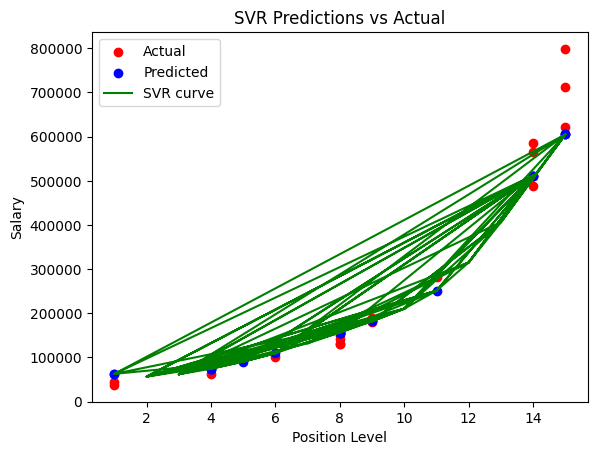

In [14]:
import matplotlib.pyplot as plt

# Predict on the test set
y_pred = regressor.predict(X_test)

# Inverse transform predictions and actuals back to original salary scale
y_pred_original = sc_y.inverse_transform(y_pred.reshape(-1,1))
y_test_original = sc_y.inverse_transform(y_test.reshape(-1,1))

# Scatter plot of actual test salaries
plt.scatter(sc_X.inverse_transform(X_test), y_test_original, color='red', label='Actual')

# Scatter plot of predicted test salaries
plt.scatter(sc_X.inverse_transform(X_test), y_pred_original, color='blue', label='Predicted')

# Optionally plot the SVR curve across all training data for smoothness
plt.plot(sc_X.inverse_transform(X_train),
         sc_y.inverse_transform(regressor.predict(X_train).reshape(-1,1)),
         color='green', label='SVR curve')

plt.title('SVR Predictions vs Actual')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend()
plt.show()

## Observations:

- **Actual values (red dots):** Show the true salaries for each position level.
- **Predicted values (blue dots):** Represent the SVR model’s predictions after training.
- **SVR regression line (green curve):** Bends smoothly to follow the overall salary trend.
- **Observation:** The predicted points stay close to the actual ones, showing that the model has captured the non‑linear relationship well without overfitting.

"The SVR model gives us one continuous curve. The multiple green line segments you see are just how matplotlib connects the predicted points. If we sample more points, the curve will look smoother."


In [15]:
import numpy as np
import pandas as pd
import gradio as gr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

# -----------------------------
# 1. Load dataset
# -----------------------------
dataset = pd.read_csv('Position_Salaries_100_Realistic.csv')
X = dataset.iloc[:, 1:-1].values   # Level
y = dataset.iloc[:, -1].values     # Salary

# -----------------------------
# 2. Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# -----------------------------
# 3. Scaling
# -----------------------------
sc_X = StandardScaler()
sc_y = StandardScaler()

X_train_scaled = sc_X.fit_transform(X_train)
X_test_scaled = sc_X.transform(X_test)

y_train_scaled = sc_y.fit_transform(y_train.reshape(-1,1))

# -----------------------------
# 4. Train SVR model
# -----------------------------
regressor = SVR(kernel='rbf')
regressor.fit(X_train_scaled, y_train_scaled.ravel())

# -----------------------------
# 5. Prediction function
# -----------------------------
def predict_salary(level):
    level_scaled = sc_X.transform(np.array([[level]]))
    pred_scaled = regressor.predict(level_scaled)
    pred_salary = sc_y.inverse_transform(pred_scaled.reshape(-1,1))[0,0]
    return round(pred_salary,2)

# -----------------------------
# 6. Gradio Interface (Level only)
# -----------------------------
with gr.Blocks() as demo:
    gr.Markdown("## SVR Salary Prediction App (Level-Based)")

    level_input = gr.Number(label="Enter Position Level (1–15)", value=5)
    salary_output = gr.Number(label="Predicted Salary")

    btn = gr.Button("Predict")

    btn.click(fn=predict_salary, inputs=level_input, outputs=salary_output)

# Launch app
demo.launch()

C:\Users\admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
